# Exploratory Data Analysis (EDA) of the Rotten Tomatoes Sentiment Dataset

## Project

Benchmarking Modern Text classification Approaches: From TF-IDF to Large Language Models

## Objective

The objective of this notebook is to explore and understand the Rotten Tomatoes sentiment dataset before developing classification models.

Specifically, we aim to:
- Understand the dataset structure
- Examine class balance
- Analyze review length characteristics
- Explore vocabulary patterns
- Investigate frequent words and n-grams
- Identify challenges that may affect classification performance

The insights obtained from this analysis will guide the design and evaluation of traditional machine learning models, transformer-based models, and large language models in later stages of the project.

In [2]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [12]:
from src.data_loader import RottenTomatoesDataLoader

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plotting style
sns.set_theme(style="whitegrid")

# Make plots larger
plt.rcParams["figure.figsize"] = (10, 6)

In [7]:
# Load the Rotten Tomatoes dataset
data_manager = RottenTomatoesDataLoader()

# Download the dataset and save it locally
dataset = data_manager.download_dataset()
data_manager.save_dataset_local(dataset)

# Load the dataset from local storage
dataset = data_manager.load_dataset_local()
dataset


2026-06-18 13:07:35,313 - INFO - Downloading dataset: cornell-movie-review-data/rotten_tomatoes
2026-06-18 13:07:35,480 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-06-18 13:07:35,494 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/cornell-movie-review-data/rotten_tomatoes/aa13bc287fa6fcab6daf52f0dfb9994269ffea28/README.md "HTTP/1.1 200 OK"
2026-06-18 13:07:35,602 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes/resolve/aa13bc287fa6fcab6daf52f0dfb9994269ffea28/rotten_tomatoes.py "HTTP/1.1 404 Not Found"
2026-06-18 13:07:35,894 - INFO - HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/cornell-movie-review-data/rotten_tomatoes/cornell-movie-review-data/rotten_tomatoes.py "HTTP/1.1 404 Not Found"
2026-06-18 13:07:36,005 - INFO - HTTP Request: HEAD https:

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})

In [ ]:
# Inspect Dataset Splits
for split_name, split in dataset.items():
    print(f"{split_name}: {len(split):,} samples")

train: 8,530 samples
validation: 1,066 samples
test: 1,066 samples


In [15]:
# Split the dataset into training set and convert to DataFrame
train_df = dataset["train"].to_pandas()

train_df.head()

,text,label
0,the rock is destined to be the 21st century's ...,1
1,"the gorgeously elaborate continuation of "" the...",1
2,effective but too-tepid biopic,1
3,if you sometimes like to go to the movies to h...,1
4,"emerges as something rare , an issue movie tha...",1


In [ ]:
# Inspect Training Set
train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8530 entries, 0 to 8529
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    8530 non-null   str  
 1   label   8530 non-null   int64
dtypes: int64(1), str(1)
memory usage: 1.1 MB


# Initial Observations

The dataset contains movie reviews and corresponding sentiment labels.

Columns:
- `text`: The movie review text
- `label`: The sentiment class

The target variable is binary:

- `0`: Negative sentiment
- `1`: Positive sentiment

No additional metadata is provided in the dataset.

In [ ]:
# Dataset Summary table
summary = pd.DataFrame(
    {
        "split": dataset.keys(),
        "Samples": [len(dataset[split]) for split in dataset.keys()],
    }
)

summary

,split,Samples
0,train,8530
1,validation,1066
2,test,1066


In [25]:
# Check for missing values in the training set
missing_count = train_df.isnull().sum()

print(f"Missing values in the training set: \n{missing_count}")

Missing values in the training set: 
text     0
label    0
dtype: int64


In [22]:
# Check for duplicate values in the training set
duplicate_count = train_df.duplicated(subset=["text"]).sum()

print(f"Duplicate reviews: {duplicate_count}")

Duplicate reviews: 0


# Data Quality Assessment

The dataset was inspected for missing values and duplicate entries. The reults indicate that there are no missing values and no duplicate entries in the training set, suggesting that the dataset is clean and ready for analysis.

In [28]:
# Label Distribution
class_distribution = train_df["label"].value_counts()

print(f"class distribution: \n\n{class_distribution}")

class distribution: 

label
1    4265
0    4265
Name: count, dtype: int64


In [ ]:
# Class Distribution Percentages
class_distribution_percent = (
    train_df["label"].value_counts(normalize=True).reset_index()
)

class_distribution_percent.columns = ["label", "percentage"]

class_distribution_percent["percentage"] = class_distribution_percent["percentage"] * 100

print(f"Class distribution percentages: \n\n{class_distribution_percent}")

Class distribution percentages: 

   label  percentage
0      1        50.0
1      0        50.0


2026-06-18 13:47:44,434 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-18 13:47:44,446 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


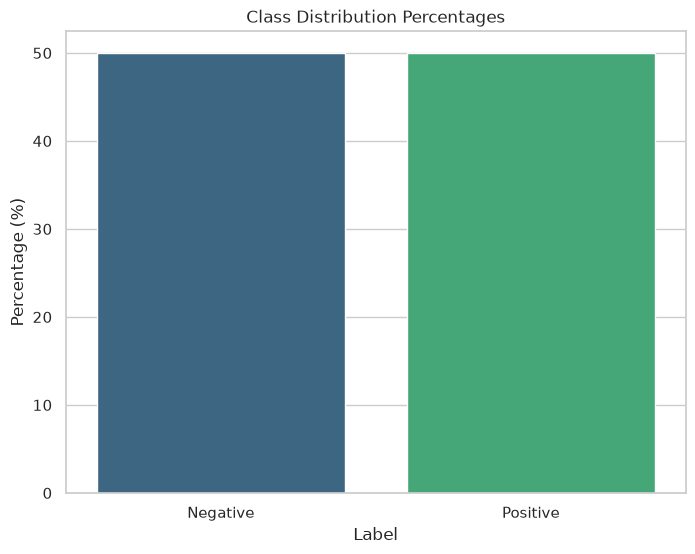

In [37]:
# Bar plot of class distribution
plt.figure(figsize=(8, 6))
sns.barplot(x="label", y="percentage", hue="label", data=class_distribution_percent, palette="viridis", legend=False)

plt.title("Class Distribution Percentages")
plt.xlabel("Label")
plt.ylabel("Percentage (%)")

plt.xticks(ticks=[0, 1], labels=["Negative", "Positive"])

plt.show()

# Interpretation of Class Distribution

The Rotten Tomatoes dataset exhibits a balanced class distribution. This balanced structure makes the dataset suitable for comparing classical machine learning models, transformer-based models, and large language moodels under fair conditions.